In [121]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from hydra import initialize, compose
from rdkit import Chem
from collections import defaultdict
from itertools import accumulate, chain
from ergochemics.mapping import rc_to_nest, get_reaction_center
from ergochemics.draw import draw_reaction, draw_molecule
from IPython.display import SVG
from cgr.ml import sep_aidx_to_bin_label, scrub_anonymous_template_atoms
from cgr.rule_writing import filter_by_pub_date
import yaml
from ast import literal_eval
import json
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    auc,
    average_precision_score
)

from sklearn.calibration import CalibrationDisplay

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

mlflow.set_tracking_uri(f"file://{cfg.mlruns}")

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

In [122]:
def get_min_dist_to_rc(am_rxn: str, rc: list[list[list[int]], list[list[int]]]) -> list[list[list[int]], list[list[int]]]:
    mols = [[Chem.MolFromSmiles(elt) for elt in side.split('.')] for side in am_rxn.split('>>')]
    min_dists = [[], []]
    for i, side_rc in enumerate(rc):
        for mol, rc in zip(mols[i], side_rc):
            for atom in mol.GetAtoms():
                aidx = atom.GetIdx()
                min_dist = min(len(Chem.GetShortestPath(mol, aidx, rcidx)) - 1 if aidx != rcidx else 0 for rcidx in rc)

                min_dists[i].append(min_dist)
    return [np.array(elt).reshape(-1, 1) for elt in min_dists]


In [123]:
experiment_name = f"outer_splits_v3"
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment:
    df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
else:
    print(f"Experiment '{experiment_name}' not found.")

In [124]:
labels = []
for _, row in df[df['params.objective'] == 'val_auprc'].iterrows():
    labels.append(
        pd.read_parquet(
            Path(row['artifact_uri'].replace("file:///home/spn1560/coarse-grain-rxns", "..")) / "predictions.parquet"
        )
    )

labels = pd.concat(labels, ignore_index=True)[['rxn_id', 'aidx', 'y']]
labels.head()

,rxn_id,aidx,y
0,d31a1334f694b47d6a71cf52dd664ae1ba4f49bd,0,0.0
1,d31a1334f694b47d6a71cf52dd664ae1ba4f49bd,1,1.0
2,d31a1334f694b47d6a71cf52dd664ae1ba4f49bd,2,1.0
3,d31a1334f694b47d6a71cf52dd664ae1ba4f49bd,3,0.0
4,d31a1334f694b47d6a71cf52dd664ae1ba4f49bd,4,0.0


In [125]:
cutoff_date = 2015
experiment_name = f"before_{cutoff_date}"
mech_probas_dir = Path(cfg.processed_data) / "mech_probas"
mech_probas_files = sorted(mech_probas_dir.glob(f"{experiment_name}*.parquet"))

if not mech_probas_files:
    raise FileNotFoundError(f"No parquet files found matching 'mech probas*.parquet' in {mech_probas_dir}")

mech_probas = pd.concat(
    [pd.read_parquet(fn) for fn in mech_probas_files],
    ignore_index=True
).groupby(["rxn_id", "aidx"]).agg({"probas": "mean"}).reset_index()

print(f"Loaded {len(mech_probas_files)} files")
mech_probas.head()

Loaded 5 files


,rxn_id,aidx,probas
0,000041cb3110fc05c5c6815bfcd7699aa7e21ed1,0,0.983065
1,000041cb3110fc05c5c6815bfcd7699aa7e21ed1,1,0.000998
2,000041cb3110fc05c5c6815bfcd7699aa7e21ed1,2,0.000404
3,000041cb3110fc05c5c6815bfcd7699aa7e21ed1,3,0.000155
4,000041cb3110fc05c5c6815bfcd7699aa7e21ed1,4,0.000089


In [126]:
pub = pd.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub.head()

,id,smarts,enzymes,reverse,db_ids,pubmed_ids,publication_dates
0,e908a824c912d1e39c46de92d1f738c92b01fdbd,**.NC(CCC(=O)NC(CS)C(=O)NCC(=O)O)C(=O)O>>*SCC(...,"[P15964, A2XMN2, P82998, P67805, P42769, O1611...",3bbe8e6dca0da1c745e7678c8efebe14bdbcaaf7,[RHEA:16438],"[28223489, 18567690, 12387854, 1417752, 111196...","[1986, 1988, 1990, 1992, 1993, 1994, 1995, 199..."
1,d86d99a8143d3be8fc861a5de5e625c502ef3124,*.*.*.*.*.*.*.*.*.*.CC(C)(COP(=O)(O)OP(=O)(O)O...,"[Q0UK48, A0A0C6E0I7, A0A0C6DWS6, Q0UK50]",e99fb0b75e799eba72aee21c1d04ee223c45f56e,[RHEA:51350],"[31553484, 25530455]","[2019, 2015]"
2,2972b2db66715ba6f3d6aeaf07f31bea536176aa,*.*.*.*.*.*.*.*.*NC(COP(=O)(O)OCC(C)(C)C(O)C(=...,"[P0DO30, G0REX6, A0A482N9V7]",5a7fffef224c65b7cd431ddc668eb2d470c617c3,[RHEA:64546],"[34947016, 30905148, 31216742]","[2019, 2021]"
3,572e4a84a946af07c9ab6fd1c0347b96aa6c4575,*.*.*.*.*.*.*.*.*OP(=O)(O)OCC(COCCC(C)CCCC(C)C...,"[Q979Y7, Q12WF0, O27753, Q9V2B0, Q8TUV8, Q2NFF...",c4c936d8d985a457a128601b8d27695883f48ef8,[RHEA:64377],"[18375567, 17288560, 22469971, 16788058, 24954...","[2006, 2007, 2008, 2012, 2014]"
4,dfe7fc761de3c213bf2b18fae4f8a56ff79abee1,*.*.*.*.*.*.*.*.CC(C)CCCC(C)CCCC(C)CCCC(C)CCOC...,"[O27753, Q9V2B0, Q8TUV8, Q2NFF7, O29786, A4FZB...",2e026380a550baa6b343604e6f550055ac9e1d3f,[RHEA:64369],"[17288560, 18375567]","[2008, 2007]"


In [127]:
pred_df = mech_probas.merge(
    labels,
    on=['rxn_id', 'aidx'],
    how='inner'
)
pred_df = pred_df.rename(columns={'probas': 'y_pred'})
pred_df = filter_by_pub_date(pub, pred_df, cutoff_date, mode="after")
pred_df.head()

,rxn_id,aidx,y_pred,y
881,004e206b7c6bdc6e7230941aefaac8a6477fe298,0,0.997236,1.0
882,004e206b7c6bdc6e7230941aefaac8a6477fe298,1,0.996179,1.0
883,004e206b7c6bdc6e7230941aefaac8a6477fe298,2,0.000936,0.0
884,004e206b7c6bdc6e7230941aefaac8a6477fe298,3,0.001157,0.0
885,004e206b7c6bdc6e7230941aefaac8a6477fe298,4,0.000785,0.0


In [128]:
roc_auc_score(pred_df['y'], pred_df['y_pred'])

np.float64(0.9968728201532279)

In [129]:
len(pred_df['rxn_id'].unique())

1434

In [130]:
full = pd.read_parquet(
    Path(cfg.raw_data) / "mapped_known_reactions_x_mechinformed_rules.parquet"
)

full = filter_by_pub_date(pub, full, cutoff_date, mode="after")
full = full[full['rxn_id'].isin(pred_df['rxn_id'].unique())]
full["template_aidxs"] = full["template_aidxs"].apply(rc_to_nest)
full['template_aidxs'] = full.apply(lambda x: scrub_anonymous_template_atoms(x.template_aidxs, x.rule), axis=1) # Scrub anonymous atoms from aidxs
full["reaction_center"] = full["am_smarts"].apply(get_reaction_center) # Get the actual reaction center from the atom mapped reactions
full["min_dist_to_rc"] = full.apply(lambda x: get_min_dist_to_rc(x.am_smarts, x.reaction_center)[0], axis=1) # Get min dist to reaction center for lhs
full["binary_label"] = full.apply(lambda x: sep_aidx_to_bin_label(x.am_smarts, x.template_aidxs)[0], axis=1) # Convert aidxs to binary labels for block mol
full.head()

,rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,reaction_center,min_dist_to_rc,binary_label
4,1df0c98f185e6581109d26af4be03ea93c490d63,CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP...,[CH3:4][C:1](=[O:2])[S:10][CH2:11][CH2:12][NH:...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((1, 2, 3), (5,)), ((5, 6, 8), (47,)))",39,"[[[1, 3], [5]], [[6, 5], [47]]]","[[1], [0], [1], [0], [1], [2], [3], [4], [5], ...","[[0.0], [1.0], [1.0], [1.0], [0.0], [0.0], [0...."
14,28cfa1867efd23f5094c66ffc2c4cf90f5ae5f88,*C(=O)C(*)NC(C)=O.CC(C)(COP(=O)(O)OP(=O)(O)OCC...,[*:56][C:54](=[O:57])[CH:53]([*:55])[NH:52][C:...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((6, 8, 5), (47,)), ((1, 2, 3), (5,)))",40,"[[[6, 5], [47]], [[1, 3], [5]]]","[[3], [2], [3], [1], [2], [0], [0], [1], [1], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [1...."
20,cd98f98adb9f4d80fbf6f52f2d46a8c6296e0960,*C(=O)C(CC(=O)O)NC(=O)C(CC(=O)O)NC(=O)C(CC(=O)...,[*:72][C:70](=[O:73])[CH:67]([CH2:71][C:74](=[...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((25, 27, 24), (47,)), ((1, 2, 3), (20,)))",40,"[[[25, 24], [47]], [[1, 3], [20]]]","[[9], [8], [9], [7], [8], [9], [10], [10], [6]...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...."
21,bd05a1037b167e98722c573096e65edcf09eca81,CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP...,[CH3:4][C:1](=[O:2])[S:29][CH2:30][CH2:31][NH:...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((1, 2, 3), (20,)), ((24, 25, 27), (47,)))",39,"[[[1, 3], [20]], [[25, 24], [47]]]","[[1], [0], [1], [0], [1], [2], [3], [4], [5], ...","[[0.0], [1.0], [1.0], [1.0], [0.0], [0.0], [0...."
23,b99292634c3f7190595a6cedae8f95dd8a84789a,*C(=O)C(CC(=O)O)NC(=O)C(CCSC)NC(C)=O.O>>CSCCC(...,[*:17][C:15](=[O:18])[CH:14]([CH2:16][C:19](=[...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((9, 10, 8), (0,)), ((9, 10, 11), (4,)))",7,"[[[9, 8], [0]], [[9, 11], [4]]]","[[3], [2], [3], [1], [2], [3], [4], [4], [0], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...."


In [131]:
rdchiral_preds = pd.read_parquet(
    Path(cfg.processed_data) / "rdchiral_predictions.parquet"
)
print(f"Loaded rdchiral predictions with shape {rdchiral_preds.shape}")
rdchiral_preds = filter_by_pub_date(pub, rdchiral_preds, cutoff_date, mode="after")
rdchiral_preds = rdchiral_preds[rdchiral_preds['rxn_id'].isin(pred_df['rxn_id'].unique())]
print(f"Filtered rdchiral predictions to shape {rdchiral_preds.shape} after applying cutoff date filter")

rdchiral_metrics = {}
rdchiral_metrics['precision'] = precision_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['recall'] = recall_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['accuracy'] = accuracy_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['f1'] = f1_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)

rxn_recovery_indicator = []
rdchiral_rxn_recall = rdchiral_preds.groupby('rxn_id').apply(
    lambda x: int((x['y_pred'] - x['y'] >= 0).all())
)
rdchiral_metrics['rxn_recall'] = rdchiral_rxn_recall.sum() / len(rdchiral_rxn_recall)

print("Rdchiral prediction metrics:")
for k, v in rdchiral_metrics.items():
    print(f"{k}: {v:.4f}")

rdchiral_preds.head()

Loaded rdchiral predictions with shape (695370, 4)
Filtered rdchiral predictions to shape (79746, 4) after applying cutoff date filter
Rdchiral prediction metrics:
precision: 0.5184
recall: 0.8626
accuracy: 0.9088
f1: 0.6476
rxn_recall: 0.5969


/tmp/ipykernel_1617686/1840052208.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rdchiral_rxn_recall = rdchiral_preds.groupby('rxn_id').apply(


,rxn_id,aidx,y,y_pred
140,1df0c98f185e6581109d26af4be03ea93c490d63,0,0.0,1
141,1df0c98f185e6581109d26af4be03ea93c490d63,1,1.0,1
142,1df0c98f185e6581109d26af4be03ea93c490d63,2,1.0,1
143,1df0c98f185e6581109d26af4be03ea93c490d63,3,1.0,1
144,1df0c98f185e6581109d26af4be03ea93c490d63,4,0.0,1


In [132]:
# min_dist_map = dict(zip(full["rxn_id"], full["min_dist_to_rc"]))
# rule_id_map = dict(zip(full["rxn_id"], full["rule_id"]))
# pred_df["rule_id"] = pred_df["rxn_id"].map(rule_id_map)
# pred_df["min_dist_to_rc"] = None
# for k in tqdm(pred_df["rxn_id"].unique(), desc="Mapping min_dist_to_rc"):
#     v = min_dist_map.get(k)
#     pred_df.loc[pred_df["rxn_id"] == k, "min_dist_to_rc"] = v.flatten()

# pred_df.head()

In [133]:
# Due to molecule symmetry and issues with ergochemics.operator_map_reaction

bad_ids = set()
for _, row in full.iterrows():
    templates = row["template_aidxs"][0]
    rcs = row["reaction_center"][0]

    for template, rc in zip(templates, rcs):
        if len(set(rc) - set(template)) != 0:
            bad_ids.add(row["rxn_id"])
print(bad_ids)

{'c0d93f65abf48b521acc2a86c0c3a5b912b68d8d', 'd04e629c46be215b30790b16aacec8c9fd4d45d2', '249d3509e1615e909e2e5272a4b65ea479ebd68e', 'bcd661a0cfbd7e3cecb47c4e1d6d9cf3e0521511', '44e0603883a147d144ba59a52fc339950b564c30', 'b360630657b1a8bf4b4e3b1e5b98deef50822778', 'e0511df0a23bd475b039a79624f852a8ec120307', 'f965c5c5f66833dfdab47e1f617a9abda3514563', '5b7ff39209cebb7f18f886c515d8d2924f4070b9', '0c3bd1d3c9f38fcec8d688de62898f0c16260331', '992b2e657b16fca16a737f194683cb7da9c72f82', '465e224d18e9fb6f3395af17fb038993afafc102', '6cd2cc89ef7d13d1f5e28b7b9a03a9af3ecd420b', '54418a132d2c138b93f8188e14601573a59c66e2', '5833b7eb2c38391507973529ae214b4f88cc06e2', '3b0ef34a88dbdbfb535437b2c4f2d568172b1992'}


In [134]:
set(full["rxn_id"]) ^ set(pred_df["rxn_id"])

set()

In [135]:
continuous_rxn_ids = []
for _, row in full.iterrows():
    continuous_rxn_ids.append(
        np.repeat(row["rxn_id"], row["binary_label"].shape[0]).reshape(-1, 1)
    )

continuous_rxn_ids = np.vstack(continuous_rxn_ids)

y = np.vstack(full["binary_label"])
min_dist_rc = np.vstack(full["min_dist_to_rc"])
Rs = [0, 1, 2, 3, 4]
rcr_preds = {R: (min_dist_rc <= R).astype(np.int32) for R in Rs}
recall_from_rcr = [recall_score(y, rcr_preds[R]) for R in Rs]
precision_from_rcr = [precision_score(y, rcr_preds[R]) for R in Rs]
recall_from_rcr, precision_from_rcr

([0.7181571815718157,
  0.8510775583946316,
  0.9210220673635308,
  0.9442508710801394,
  0.9908375274228933],
 [0.9941050375133976,
  0.5933957171135504,
  0.40438551759306474,
  0.304684572142411,
  0.2505629344385341])

In [136]:
recall_from_rcr, precision_from_rcr

([0.7181571815718157,
  0.8510775583946316,
  0.9210220673635308,
  0.9442508710801394,
  0.9908375274228933],
 [0.9941050375133976,
  0.5933957171135504,
  0.40438551759306474,
  0.304684572142411,
  0.2505629344385341])

GNN AUPRC: 0.977742122548939
RC + R AUPRC: 0.8754929177977135


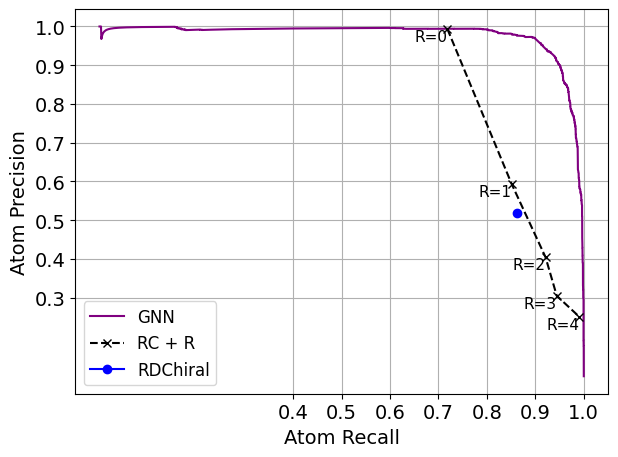

In [137]:
# RC + R stats
r_labels = [f"R={i}" for i in range(len(recall_from_rcr))]

precision, recall, thresholds = precision_recall_curve(pred_df.y, pred_df.y_pred)
fig, ax = plt.subplots()
ax.plot(recall, precision, color='purple', label="GNN")
ax.plot(recall_from_rcr, precision_from_rcr, ls='--', marker="x", color='black', label="RC + R")
print("GNN AUPRC:", auc(recall, precision))
print("RC + R AUPRC:", auc([0] + recall_from_rcr, [precision_from_rcr[0]] + precision_from_rcr))
ax.plot(
    rdchiral_metrics['recall'],
    rdchiral_metrics['precision'],
    marker='o',
    color='blue',
    label='RDChiral'
)
ax.set_xticks(np.arange(0.4, 1.05, 0.1))
ax.set_yticks(np.arange(0.3, 1.05, 0.1))
# ax.set_xlim(0.5, 1.05)
ax.set_xlabel("Atom Recall")
ax.set_ylabel("Atom Precision")
for r, p, label in zip(recall_from_rcr, precision_from_rcr, r_labels):
    ax.text(r, p, label, fontsize=11, ha='right', va='top', color='black')
ax.grid()
ax.legend(loc='lower left')
plt.tight_layout()
# fig.savefig(Path(cfg.figures) / "atom_precision_recall_curve.svg", format='svg')
plt.show()

In [103]:
ep = 3e-3
dts = []
for R, prec, rec_rcr in zip(Rs, precision_from_rcr, recall_from_rcr):
    print(f"Precision | {prec:.2f}")
    argequal_prec = np.flatnonzero(np.abs(precision - prec) < ep)[:-1]
    argmax_rec = np.argmax(recall[argequal_prec])
    print(f"Recall | GNN: {recall[argequal_prec][argmax_rec]:.2f} vs RC + {R}: {rec_rcr:.2f}")
    print(f"Threshold | {thresholds[argequal_prec][argmax_rec]:.3f}\n")
    dts.append(float(thresholds[argequal_prec][argmax_rec]))

print(dts)

Precision | 0.99
Recall | GNN: 0.81 vs RC + 0: 0.73
Threshold | 0.898

Precision | 0.60
Recall | GNN: 0.99 vs RC + 1: 0.86
Threshold | 0.038

Precision | 0.41


ValueError: attempt to get argmax of an empty sequence

In [ ]:
rxn_recall_from_rcr = []
for R in Rs:
    print(f"Calculating reaction recall from RCR for R={R}")
    preds = rcr_preds[R]
    rxn_recovery_indicator = []
    for rxn_id in tqdm(np.unique(continuous_rxn_ids), total=len(np.unique(continuous_rxn_ids)), desc="Processing reactions"):
        if (preds[continuous_rxn_ids == rxn_id] - y[continuous_rxn_ids == rxn_id] >= 0).all():
            rxn_recovery_indicator.append(1)
        else:
            rxn_recovery_indicator.append(0)
    
    rxn_recall_from_rcr.append(sum(rxn_recovery_indicator) / len(rxn_recovery_indicator))

Calculating reaction recall from RCR for R=0


Processing reactions: 100%|██████████| 12137/12137 [03:54<00:00, 51.83it/s] 


Calculating reaction recall from RCR for R=1


Processing reactions: 100%|██████████| 12137/12137 [04:17<00:00, 47.20it/s] 


Calculating reaction recall from RCR for R=2


Processing reactions: 100%|██████████| 12137/12137 [04:07<00:00, 48.95it/s] 


Calculating reaction recall from RCR for R=3


Processing reactions: 100%|██████████| 12137/12137 [04:39<00:00, 43.35it/s] 


Calculating reaction recall from RCR for R=4


Processing reactions: 100%|██████████| 12137/12137 [04:37<00:00, 43.71it/s] 


In [ ]:
rxn_recall = []
ds = 1_000
for dt in tqdm(thresholds[::ds], total=len(thresholds[::ds]), desc="Calculating reaction recall from GNN"):
    rxn_recovery_indicator = []
    for rxn_id, group in pred_df.groupby("rxn_id"):
        preds = (group.y_pred >= dt).astype(np.int32).to_numpy()
        ytrue = group.y.to_numpy()
        if (preds - ytrue >= 0).all():
            rxn_recovery_indicator.append(1)
        else:
            rxn_recovery_indicator.append(0)

    rxn_recall.append(sum(rxn_recovery_indicator) / len(rxn_recovery_indicator))

Calculating reaction recall from GNN:   0%|          | 0/102 [00:00<?, ?it/s]

Calculating reaction recall from GNN: 100%|██████████| 102/102 [03:12<00:00,  1.89s/it]


GNN AUPRC: 0.8492295929293273
RC + R AUPRC: 0.5931539323570362


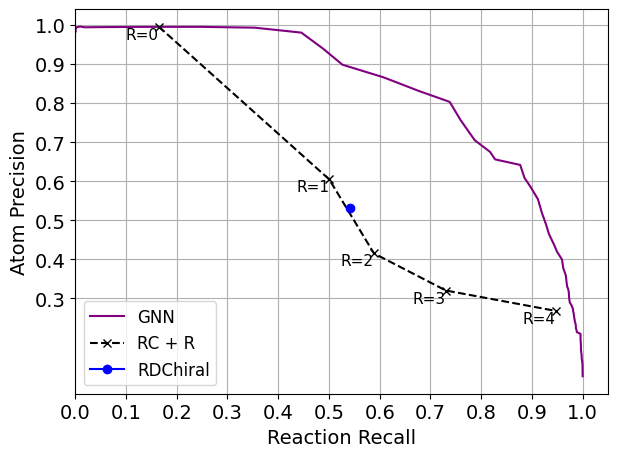

In [ ]:
fig, ax = plt.subplots()
ax.plot(rxn_recall, precision[::ds], color='purple', label="GNN")
ax.plot(rxn_recall_from_rcr, precision_from_rcr, ls='--', marker="x", color='black', label="RC + R")
print("GNN AUPRC:", auc(rxn_recall, precision[::ds]))
print("RC + R AUPRC:", auc([0] + rxn_recall_from_rcr, [precision_from_rcr[0]] + precision_from_rcr))
ax.plot(
    rdchiral_metrics['rxn_recall'],
    rdchiral_metrics['precision'],
    marker='o',
    color='blue',
    label='RDChiral'
)
ax.set_xticks(np.arange(0.0, 1.05, 0.1))
ax.set_yticks(np.arange(0.3, 1.05, 0.1))
ax.set_xlim(0.0, 1.05)
ax.set_xlabel("Reaction Recall")
ax.set_ylabel("Atom Precision")
for r, p, label in zip(rxn_recall_from_rcr, precision_from_rcr, r_labels):
    ax.text(r, p, label, fontsize=11, ha='right', va='top', color='black')
ax.grid()
ax.legend(loc='lower left')
plt.tight_layout()
fig.savefig(Path(cfg.figures) / "atom_precision_reaction_recall_curve.svg", format='svg')
plt.show()